# Noise and decoding: from physical error to logical failure

This notebook runs the complete experiment pipeline -- sample a physical Pauli error, extract its syndrome, decode a correction, and classify the residual -- using the public `homoloqode` API end to end, for two small toric codes.

**Research question.** How does a small toric code, decoded with a deliberately exhaustive (exponential-time) decoder, behave under a simple independent Pauli noise channel?

**Limitations, stated up front:**

* These are finite, small-code experiments ($L=2,3$ only) -- not an asymptotic or scaling study.
* The decoder (`homoloqode.decoders.decode_syndrome`) is exponential in the number of qubits; it is a correctness reference, not a scalable decoder.
* The results below are **not a threshold estimate**. A real threshold requires much larger codes and many more samples than are practical here.
* The noise model (`IndependentPauliNoise`) is a simple per-qubit I/X/Y/Z channel: it does not model measurement errors or correlated errors.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from homoloqode import toric_code, exact_distance, square_toric_complex
from homoloqode.noise import IndependentPauliNoise
from homoloqode.decoders import decode_syndrome, classify_residual, ResidualClass
from homoloqode.experiments import run_memory_trial, run_memory_experiment
from homoloqode.visualization import plot_square_toric_complex

from homoloqode.algebra import rank


## 1. Reference codes

We use the two toric-code fixtures already validated elsewhere in the project: $L=2$ (the smallest nontrivial case) and $L=3$.

In [2]:
code_l2 = toric_code(2)
code_l3 = toric_code(3)

for label, code_ in [("L=2", code_l2), ("L=3", code_l3)]:
    n, k = code_.n, code_.n - rank(code_.hx) - rank(code_.hz)
    d = exact_distance(code_)
    print(f"{label}: n={n}, k={k}, rank(H_X)={rank(code_.hx)}, rank(H_Z)={rank(code_.hz)}, "
          f"d_x={d.d_x}, d_z={d.d_z}, d={d.d}")

assert (code_l2.n, code_l2.n - rank(code_l2.hx) - rank(code_l2.hz)) == (8, 2)
assert (code_l3.n, code_l3.n - rank(code_l3.hx) - rank(code_l3.hz)) == (18, 2)
assert exact_distance(code_l2).d == 2
assert exact_distance(code_l3).d == 3
print("\nParameters confirmed: L=2 is [[8,2,2]], L=3 is [[18,2,3]]")

L=2: n=8, k=2, rank(H_X)=3, rank(H_Z)=3, d_x=2, d_z=2, d=2
L=3: n=18, k=2, rank(H_X)=8, rank(H_Z)=8, d_x=3, d_z=3, d=3

Parameters confirmed: L=2 is [[8,2,2]], L=3 is [[18,2,3]]


## 2. One complete trial, in detail

`run_memory_trial` chains sampling, syndrome extraction, decoding, and residual classification into a single call. We fix the seed so this cell's output is identical on every run.

Sampled error (Pauli string): IIIIIXIIIXIIIIIIII
Non-identity qubits: [('e_h[2,1]', 'X'), ('e_v[0,0]', 'X')]

Syndrome vectors:
  x_checks: [0 0 0 0 0 0 0 0 0]
  z_checks: [1 0 0 0 0 1 0 0 0]

Violated X-checks (detect Z-errors): []
Violated Z-checks (detect X-errors): ['f[0,0]', 'f[2,1]']

Decoder's X-correction support: [0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
Decoder's Z-correction support: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Residual (error XOR correction), X: [0 0 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0]
Residual, Z: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Final classification: ResidualClass.STABILIZER -> succeeded: True


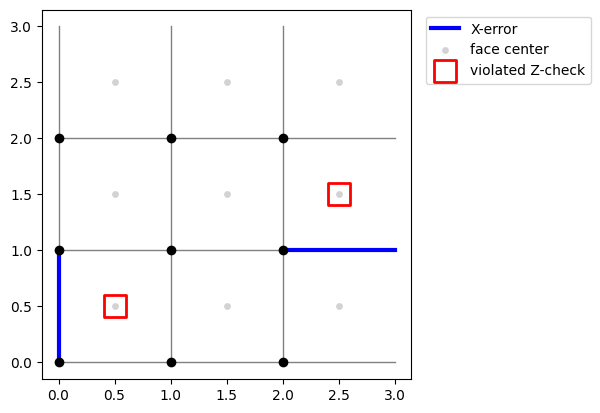

In [3]:
demo_noise = IndependentPauliNoise(p_x=0.05, p_y=0.0, p_z=0.05)
demo_rng = np.random.default_rng(0)
trial = run_memory_trial(code_l3, demo_noise, rng=demo_rng)

print("Sampled error (Pauli string):", trial.error.to_pauli_string())
nonidentity = [(label, "X" if x and not z else "Z" if z and not x else "Y")
               for label, x, z in zip(code_l3.qubit_labels, trial.error.x, trial.error.z) if x or z]
print("Non-identity qubits:", nonidentity)

print("\nSyndrome vectors:")
print("  x_checks:", trial.syndrome.x_checks)
print("  z_checks:", trial.syndrome.z_checks)

fired_x = [label for label, bit in zip(code_l3.x_check_labels, trial.syndrome.x_checks) if bit]
fired_z = [label for label, bit in zip(code_l3.z_check_labels, trial.syndrome.z_checks) if bit]
print("\nViolated X-checks (detect Z-errors):", fired_x)
print("Violated Z-checks (detect X-errors):", fired_z)

print("\nDecoder's X-correction support:", trial.decode_result.x_correction.support)
print("Decoder's Z-correction support:", trial.decode_result.z_correction.support)

residual_x = np.bitwise_xor(trial.error.x, trial.decode_result.x_correction.support)
residual_z = np.bitwise_xor(trial.error.z, trial.decode_result.z_correction.support)
print("\nResidual (error XOR correction), X:", residual_x)
print("Residual, Z:", residual_z)
print("\nFinal classification:", trial.residual_class, "-> succeeded:", trial.succeeded)

fig, ax = plot_square_toric_complex(
    square_toric_complex(3),
    x_error=trial.error.x, z_error=trial.error.z,
    x_syndrome=trial.syndrome.x_checks, z_syndrome=trial.syndrome.z_checks,
)
plt.show()

## 3. Zero-noise sanity check

With every error probability at zero, every trial must succeed: no logical failures, no invalid residuals, every trial a stabilizer success.

In [4]:
zero_noise = IndependentPauliNoise(p_x=0.0, p_y=0.0, p_z=0.0)
zero_result = run_memory_experiment(code_l3, zero_noise, trials=50, seed=1)

print(zero_result)
assert zero_result.logical_failures == 0
assert zero_result.invalid_failures == 0
assert zero_result.stabilizer_successes == zero_result.trials
print("\nZero-noise sanity check passed.")

MemoryExperimentResult(trials=50, stabilizer_successes=50, logical_failures=0, invalid_failures=0, seed=1)

Zero-noise sanity check passed.


## 4. Probability sweep

A short, documented list of physical error probabilities, with trial counts small enough to stay fast under the exhaustive decoder and CI's time budget. Each probability is split evenly between X and Z (no Y component), with an explicit seed per run.

In [5]:
PROBABILITIES = [0.01, 0.02, 0.04, 0.06, 0.08, 0.10]
TRIALS = 200

sweep_rows = []
for L, code_ in [(2, code_l2), (3, code_l3)]:
    n = code_.n
    k = n - rank(code_.hx) - rank(code_.hz)
    d = exact_distance(code_).d
    for p in PROBABILITIES:
        noise = IndependentPauliNoise(p_x=p / 2, p_y=0.0, p_z=p / 2)
        result = run_memory_experiment(code_, noise, trials=TRIALS, seed=L * 1000 + int(p * 1000))
        sweep_rows.append({
            "L": L, "n": n, "k": k, "d": d, "p": p, "trials": TRIALS,
            "logical_failures": result.logical_failures,
            "logical_failure_rate": result.logical_failure_rate,
        })

print(f"Ran {len(sweep_rows)} experiments.")

# Explicit result-consistency check: each row's stored rate must equal
# logical_failures / trials exactly, and failures can never exceed trials.
for row in sweep_rows:
    assert 0 <= row["logical_failures"] <= row["trials"]
    assert row["logical_failure_rate"] == row["logical_failures"] / row["trials"]
print("Result consistency check passed for all", len(sweep_rows), "rows.")

Ran 12 experiments.
Result consistency check passed for all 12 rows.


## 5. Results table

In [6]:
header = f"{'L':>3} {'n':>4} {'k':>3} {'d':>3} {'p':>6} {'trials':>7} {'log. failures':>14} {'log. failure rate':>19}"
print(header)
print("-" * len(header))
for row in sweep_rows:
    print(f"{row['L']:>3} {row['n']:>4} {row['k']:>3} {row['d']:>3} {row['p']:>6.2f} "
          f"{row['trials']:>7} {row['logical_failures']:>14} {row['logical_failure_rate']:>19.3f}")

  L    n   k   d      p  trials  log. failures   log. failure rate
------------------------------------------------------------------
  2    8   2   2   0.01     200              7               0.035
  2    8   2   2   0.02     200             19               0.095
  2    8   2   2   0.04     200             20               0.100
  2    8   2   2   0.06     200             47               0.235
  2    8   2   2   0.08     200             55               0.275
  2    8   2   2   0.10     200             66               0.330
  3   18   2   3   0.01     200              0               0.000
  3   18   2   3   0.02     200              1               0.005
  3   18   2   3   0.04     200              4               0.020
  3   18   2   3   0.06     200              4               0.020
  3   18   2   3   0.08     200             19               0.095
  3   18   2   3   0.10     200             22               0.110


## 6. Logical failure rate vs. physical error probability

We deliberately do **not** infer a threshold from where these two small curves might cross -- that requires much larger codes and far more samples than a small, fast notebook can provide.

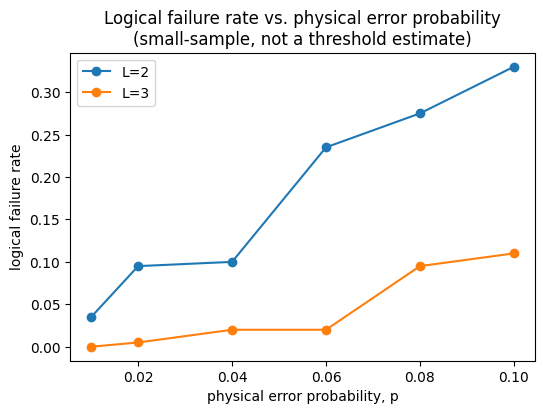

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
for L in (2, 3):
    xs = [row["p"] for row in sweep_rows if row["L"] == L]
    ys = [row["logical_failure_rate"] for row in sweep_rows if row["L"] == L]
    ax.plot(xs, ys, marker="o", label=f"L={L}")

ax.set_xlabel("physical error probability, p")
ax.set_ylabel("logical failure rate")
ax.set_title("Logical failure rate vs. physical error probability\n(small-sample, not a threshold estimate)")
ax.legend()
plt.show()

## 7. A deterministic logical-failure example

Rather than wait for a rare sampled event, we construct one directly: a representative of a logical $X$ operator -- by definition, a noncontractible loop on the torus -- run through the full decode pipeline, deterministically.

In [8]:
logicals = code_l3.logical_basis()
logical_x_support = logicals.x[0]
print("Logical X representative (edge support):", logical_x_support)
print("Weight:", int(logical_x_support.sum()), "-- matches the code distance d =", exact_distance(code_l3).d)

zero_z = np.zeros(code_l3.n, dtype=np.uint8)
deterministic_syndrome = code_l3.syndrome(x_error=logical_x_support, z_error=zero_z)
print("\nSyndrome of this operator (both zero -- it commutes with every check):")
print("  x_checks:", deterministic_syndrome.x_checks)
print("  z_checks:", deterministic_syndrome.z_checks)

decode_result = decode_syndrome(code_l3, deterministic_syndrome)
print("\nDecoder's correction for a zero syndrome:")
print("  x_correction:", decode_result.x_correction.support, "(weight", decode_result.x_correction.weight, ")")
print("  z_correction:", decode_result.z_correction.support, "(weight", decode_result.z_correction.weight, ")")

residual_x = np.bitwise_xor(logical_x_support, decode_result.x_correction.support)
residual_z = np.bitwise_xor(zero_z, decode_result.z_correction.support)
print("\nResidual (still equals the original operator, since the correction was zero):", residual_x)

classification = classify_residual(code_l3, x_residual=residual_x, z_residual=residual_z)
print("\nClassification of this residual:", classification)
assert classification is ResidualClass.LOGICAL

print(
    "\nThis operator commutes with every stabilizer (zero syndrome), so the decoder --"
    " correctly, given only the syndrome -- proposes the zero correction. But the operator"
    " itself is not a stabilizer: it is a nontrivial cycle wrapping one of the torus's two"
    " independent noncontractible loops. The residual therefore remains exactly this logical"
    " operator, and is classified LOGICAL: a deterministic, end-to-end demonstration of the"
    " error/correction/residual failure mechanism, with no random sampling involved."
)

Logical X representative (edge support): [1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
Weight: 3 -- matches the code distance d = 3

Syndrome of this operator (both zero -- it commutes with every check):
  x_checks: [0 0 0 0 0 0 0 0 0]
  z_checks: [0 0 0 0 0 0 0 0 0]

Decoder's correction for a zero syndrome:
  x_correction: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] (weight 0 )
  z_correction: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] (weight 0 )

Residual (still equals the original operator, since the correction was zero): [1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0]

Classification of this residual: ResidualClass.LOGICAL

This operator commutes with every stabilizer (zero syndrome), so the decoder -- correctly, given only the syndrome -- proposes the zero correction. But the operator itself is not a stabilizer: it is a nontrivial cycle wrapping one of the torus's two independent noncontractible loops. The residual therefore remains exactly this logical operator, and is classified LOGICAL: a deterministic, 

## 8. Interpretation

**What the code distance predicts, and what it does not.** Suppose the real error is $E$ and the decoder returns correction $C$. The decoder always returns a *minimum-weight* correction consistent with the observed syndrome, and $E$ itself is one such consistent correction (it trivially reproduces its own syndrome), so $|C| \leq |E|$. If decoding fails, the residual $E \oplus C$ is a nontrivial logical operator, so by definition of the code distance $d$, $|E \oplus C| \geq d$. Combined with the triangle inequality for Hamming weight, $|E \oplus C| \leq |E| + |C| \leq 2|E|$, so $d \leq 2|E|$, i.e. $|E| \geq d/2$. **Contrapositive: any error of weight strictly less than $d/2$ can never cause a logical failure** -- this is a hard guarantee, not a tendency. Failure only becomes *possible* once $|E| \geq d/2$ (including exact ties when $d$ is even), and even then it is not certain: some errors at or above $d/2$ are still corrected successfully.

**Why minimum-weight decoding can fail even when a lower-weight correction exists in principle.** The decoder returns the exact minimum-weight correction consistent with the observed syndrome (Sections 2, MVP-05). Failure does not mean the decoder made a suboptimal choice -- it means the *true* minimum-weight correction, XORed with the real error, happens to be a nontrivial logical operator rather than a stabilizer. This is a structural property of the code and the specific error, not a decoder bug.

**Stabilizer degeneracy.** Many different physical errors share the same syndrome. Section 2's own worked trial demonstrates this directly: the decoder's chosen correction was a genuinely different vector from the sampled error, yet still reproduced an identical syndrome and was classified a stabilizer success. (The zero-noise check in Section 3 does **not** demonstrate this -- there, both the injected error and the decoder's correction are the zero vector, so no degeneracy is actually exercised.) This is precisely why residual classification -- not raw error/correction equality -- is the right success criterion.

**Sample-size limitations.** `TRIALS = 200` per point (Section 4) is fast enough for CI but far too small to resolve a real threshold or give tight statistical error bars -- the logical failure rates in Section 5's table should be read as rough estimates, not precise measurements.

**What this noise model leaves out.** `IndependentPauliNoise` has no measurement error (syndrome extraction is treated as perfect) and no correlated errors (each qubit's error is independent of every other). Real hardware has both.

**Next steps toward scalable decoding.** This decoder's exponential search is only tractable at these small sizes (`max_qubits` guards against accidental misuse -- see MVP-03/MVP-05). A genuinely scalable pipeline needs a polynomial-time decoder (e.g. minimum-weight perfect matching for surface-code-like structure, or belief propagation for general LDPC codes), many more trials per data point, and larger code sizes to see genuine threshold behavior emerge.